# **GENERAL EDA**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import scipy.stats as stats
from sklearn import preprocessing
from sklearn.impute import IterativeImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
import plotly.express as px
from wordcloud import WordCloud
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from scipy.stats import pearsonr, spearmanr, anderson
from scipy import stats
from statsmodels.graphics.gofplots import qqplot
import statsmodels.api as sm
from sklearn.impute import SimpleImputer
from scipy.stats import chi2_contingency



In [ ]:
class DataFrame_Loader:


    def __init__(self):

        print("Loading DataFrame")

    def read_csv(self,data):
        self.df = pd.read_csv(data)
        return self.df

In [ ]:
class EDA_Data:

    def __init__(self):
        print("EDA_Dataframe_Analysis object created")

    def show_dtypes(self, df):
        return df.dtypes

    def show_columns(self, df):
        return df.columns

    def show_missing(self, df):
        return df.isna().sum()

    def show_hist(self, df):
        return df.hist()

    def tabulation(self, df):
        table = pd.DataFrame(df.dtypes, columns=['Dtype'])
        table = table.reset_index().rename(columns={'index': 'Name'})
        table['No of Missing'] = df.isnull().sum().values
        table['No of Uniques'] = df.nunique().values
        table['% Missing'] = (df.isnull().sum().values / df.shape[0]) * 100

        for i in range(min(3, len(df))):
            table[f'Observation {i+1}'] = df.iloc[i].values

        table['Entropy'] = table['Name'].apply(
            lambda col: round(stats.entropy(df[col].value_counts(normalize=True), base=2), 2)
            if df[col].nunique() > 1 else 0
        )

        return table

    def numerical_variables(self, df):
        return df.select_dtypes(exclude="object")

    def categorical_variables(self, df):
        return df.select_dtypes(include="object")

    def drop_na(self, df):
        return df.dropna()

    def show_pearsonr(self, x, y):
        return pearsonr(x, y)

    def show_spearmanr(self, x, y):
        return spearmanr(x, y)

    def plotly_scatter(self, df, x, y):
        fig = px.scatter(df, x=x, y=y)
        fig.update_traces(marker=dict(size=10, line=dict(width=2, color='DarkSlateGrey')))
        fig.show()

    def show_displot(self, x):
        plt.figure(figsize=(12, 6))
        plt.subplot(1, 2, 1)
        sns.histplot(x, kde=True)

        plt.subplot(1, 2, 2)
        x.plot.box(figsize=(8, 4))

        plt.tight_layout()
        plt.show()

    def show_countplot(self, x):
        fig, ax = plt.subplots(figsize=(16, 6))
        return sns.countplot(x=x, ax=ax)

    def plotly_histogram(self, df, x, y=None):
        fig = px.histogram(df, x=x, y=y)
        fig.show()

    def plotly_violin(self, df, x, y):
        fig = px.violin(df, x=x, y=y, box=True, points="all")
        fig.show()

    def show_pairplot(self, df):
        return sns.pairplot(df)

    def show_heatmap(self, df):
        plt.figure(figsize=(15, 15))
        return sns.heatmap(df.corr(), annot=True)

    def show_wordcloud(self, series):
        text = " ".join(series.astype(str))
        wordcloud = WordCloud(width=1000, height=500).generate(text)
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis("off")
        plt.show()
        return wordcloud

    def label_encode(self, x):
        le = LabelEncoder()
        return le.fit_transform(x)

    def concat(self, *dfs, axis=0):
        return pd.concat(dfs, axis=axis)

    def get_dummies(self, df):
        return pd.get_dummies(df)

    def show_qqplot(self, x):
        return qqplot(x, line='45')

    def anderson_test(self, x):
        return anderson(x)

    def apply_pca(self, df, n_components=8):
        pca = PCA(n_components=n_components)
        components = pca.fit_transform(df)
        return pd.DataFrame(components)

    def detect_outliers(self, x):
        q1 = x.quantile(0.25)
        q3 = x.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        return x[(x < lower) | (x > upper)]

    def check_cat_relation(self, x, y, confidence_level=0.95):
        cross_tab = pd.crosstab(x, y)
        stat, p, dof, expected = chi2_contingency(cross_tab)
        alpha = 1 - confidence_level
        print(f"Chi-square: {stat:.4f}, p-value: {p:.4f}")
        if p > alpha:
            print(">> Accepting Null Hypothesis: No significant relationship.")
        else:
            print(">> Rejecting Null Hypothesis: Significant relationship.")
        return p, alpha




,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [ ]:
df.tail()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
11909,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,46120
11910,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,56670
11911,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50620
11912,Acura,ZDX,2013,premium unleaded (recommended),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50920
11913,Lincoln,Zephyr,2006,regular unleaded,221.0,6.0,AUTOMATIC,front wheel drive,4.0,Luxury,Midsize,Sedan,26,17,61,28995


In [ ]:
import pandas as pd
import numpy as np


class AttributeInformation:

    def __init__(self):
        print("AttributeInformation object created")

    def column_information(self, data: pd.DataFrame) -> pd.DataFrame:
        """Provides basic attribute info of the dataset"""
        data_info = pd.DataFrame(
            columns=[
                'No of observations',
                'No of Variables',
                'No of Numerical Variables',
                'No of Factor Variables',
                'No of Categorical Variables',
                'No of Logical Variables',
                'No of Date Variables',
                'No of zero variance variables'
            ]
        )

        data_info.loc[0, 'No of observations'] = data.shape[0]
        data_info.loc[0, 'No of Variables'] = data.shape[1]
        data_info.loc[0, 'No of Numerical Variables'] = data.select_dtypes(include=[np.number]).shape[1]
        data_info.loc[0, 'No of Factor Variables'] = data.select_dtypes(include='category').shape[1]
        data_info.loc[0, 'No of Categorical Variables'] = data.select_dtypes(include='object').shape[1]
        data_info.loc[0, 'No of Logical Variables'] = data.select_dtypes(include='bool').shape[1]
        data_info.loc[0, 'No of Date Variables'] = data.select_dtypes(include='datetime64').shape[1]
        data_info.loc[0, 'No of zero variance variables'] = data.loc[:, data.nunique() == 1].shape[1]

        data_info = data_info.transpose()
        data_info.columns = ['Value']
        data_info['Value'] = data_info['Value'].astype(int)

        return data_info

    def get_missing_values(self, data: pd.DataFrame) -> pd.Series:
        """Returns a Series of missing values sorted in descending order"""
        missing_values = data.isnull().sum()
        return missing_values[missing_values > 0].sort_values(ascending=False)

    def _iqr(self, x: pd.Series) -> float:
        return x.quantile(0.75) - x.quantile(0.25)

    def _outlier_count(self, x: pd.Series) -> int:
        """Calculates outliers using IQR method"""
        upper = x.quantile(0.75) + 1.5 * self._iqr(x)
        lower = x.quantile(0.25) - 1.5 * self._iqr(x)
        return ((x > upper) | (x < lower)).sum()

    def num_count_summary(self, df: pd.DataFrame) -> pd.DataFrame:
        """Summary of numerical features in terms of count distributions"""
        df_num = df.select_dtypes(include=[np.number])
        summary = pd.DataFrame()

        for col in df_num.columns:
            summary.loc[col, 'Negative values count'] = (df_num[col] < 0).sum()
            summary.loc[col, 'Positive values count'] = (df_num[col] > 0).sum()
            summary.loc[col, 'Zero count'] = (df_num[col] == 0).sum()
            summary.loc[col, 'Unique count'] = df_num[col].nunique()
            summary.loc[col, 'Negative Infinity count'] = (df_num[col] == -np.inf).sum()
            summary.loc[col, 'Positive Infinity count'] = (df_num[col] == np.inf).sum()
            summary.loc[col, 'Missing Percentage'] = df_num[col].isnull().mean() * 100
            summary.loc[col, 'Count of outliers'] = self._outlier_count(df_num[col])

        return summary

    def statistical_summary(self, df: pd.DataFrame) -> pd.DataFrame:
        """Returns a statistical summary including percentiles"""
        df_num = df.select_dtypes(include=[np.number])
        if df_num.empty:
            return pd.DataFrame()

        try:
            stats_df = df_num.describe().transpose()
            stats_df['10%'] = df_num.quantile(0.10)
            stats_df['90%'] = df_num.quantile(0.90)
            stats_df['95%'] = df_num.quantile(0.95)
            stats_df = stats_df.rename(columns={
                '25%': 'Q1', '50%': 'Median', '75%': 'Q3'
            })
        except Exception as e:
            print("Error in statistical_summary:", e)
            stats_df = pd.DataFrame()

        return stats_df


In [ ]:
df.size

190624

In [ ]:
df.shape

(11914, 16)

In [ ]:
df.dtypes

,0
Make,object
Model,object
Year,int64
Engine Fuel Type,object
Engine HP,float64
Engine Cylinders,float64
Transmission Type,object
Driven_Wheels,object
Number of Doors,float64
Market Category,object


In [ ]:
df.columns

Index(['Make', 'Model', 'Year', 'Engine Fuel Type', 'Engine HP',
       'Engine Cylinders', 'Transmission Type', 'Driven_Wheels',
       'Number of Doors', 'Market Category', 'Vehicle Size', 'Vehicle Style',
       'highway MPG', 'city mpg', 'Popularity', 'MSRP'],
      dtype='object')

In [ ]:
df.isna().sum()

,0
Make,0
Model,0
Year,0
Engine Fuel Type,3
Engine HP,69
Engine Cylinders,30
Transmission Type,0
Driven_Wheels,0
Number of Doors,6
Market Category,3742


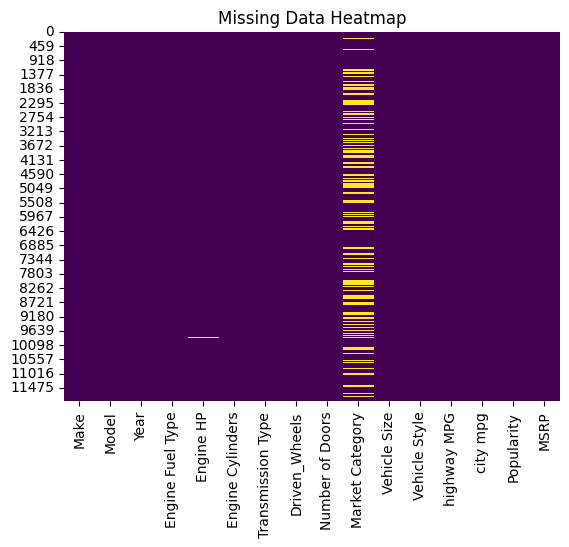

In [ ]:


sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Data Heatmap")
plt.show()

In [ ]:
df.dropna()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,46120
11910,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,56670
11911,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50620
11912,Acura,ZDX,2013,premium unleaded (recommended),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50920


In [ ]:
df.describe()

,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,MSRP
count,11914.000000,11845.00000,11884.000000,11908.000000,11914.000000,11914.000000,11914.000000,1.191400e+04
mean,2010.384338,249.38607,5.628829,3.436093,26.637485,19.733255,1554.911197,4.059474e+04
std,7.579740,109.19187,1.780559,0.881315,8.863001,8.987798,1441.855347,6.010910e+04
min,1990.000000,55.00000,0.000000,2.000000,12.000000,7.000000,2.000000,2.000000e+03
25%,2007.000000,170.00000,4.000000,2.000000,22.000000,16.000000,549.000000,2.100000e+04
50%,2015.000000,227.00000,6.000000,4.000000,26.000000,18.000000,1385.000000,2.999500e+04
75%,2016.000000,300.00000,6.000000,4.000000,30.000000,22.000000,2009.000000,4.223125e+04
max,2017.000000,1001.00000,16.000000,4.000000,354.000000,137.000000,5657.000000,2.065902e+06


In [ ]:

print("Numerical Variables:")
print(df.select_dtypes(include=['int64', 'float64']).columns)


print("\nCategorical Variables:")
print(df.select_dtypes(include=['object', 'category']).columns)

Numerical Variables:
Index(['Year', 'Engine HP', 'Engine Cylinders', 'Number of Doors',
       'highway MPG', 'city mpg', 'Popularity', 'MSRP'],
      dtype='object')

Categorical Variables:
Index(['Make', 'Model', 'Engine Fuel Type', 'Transmission Type',
       'Driven_Wheels', 'Market Category', 'Vehicle Size', 'Vehicle Style'],
      dtype='object')


Vehicle Size,Compact,Large,Midsize
Make,,,
Acura,179.080645,NaN,266.242105
Alfa Romeo,237.000000,NaN,NaN
Aston Martin,451.632653,504.857143,523.729730
Audi,265.385827,360.547619,265.641509
BMW,276.378378,402.576923,315.021978
Bentley,NaN,498.891892,568.810811
Bugatti,1001.000000,NaN,NaN
Buick,142.625000,250.716418,222.783505
Cadillac,310.869565,345.964758,316.267327


In [ ]:
# 1. Make vs Vehicle Size
crosstab_make_size = pd.crosstab(df['Make'], df['Vehicle Size'], margins=True)

# 2. Make vs Transmission Type
crosstab_make_trans = pd.crosstab(df['Make'], df['Transmission Type'], margins=True)

# 3. Vehicle Style vs Driven Wheels
crosstab_style_drive = pd.crosstab(df['Vehicle Style'], df['Driven_Wheels'], margins=True)

# 4. Vehicle Size vs Market Category
crosstab_size_market = pd.crosstab(df['Vehicle Size'], df['Market Category'], margins=True)

# 5. Transmission Type vs Vehicle Style
crosstab_trans_style = pd.crosstab(df['Transmission Type'], df['Vehicle Style'], margins=True)

# 6. Mean Engine HP by Make and Vehicle Size
crosstab_hp_make_size = pd.crosstab(df['Make'], df['Vehicle Size'], values=df['Engine HP'], aggfunc='mean', margins=True)

# 7. Mean MSRP by Market Category and Vehicle Style
crosstab_msrp_market_style = pd.crosstab(df['Market Category'], df['Vehicle Style'], values=df['MSRP'], aggfunc='mean', margins=True)

# Combine into a dictionary (for organized access in code)
combined_crosstabs = {
    'Make vs Vehicle Size': crosstab_make_size,
    'Make vs Transmission Type': crosstab_make_trans,
    'Vehicle Style vs Driven Wheels': crosstab_style_drive,
    'Vehicle Size vs Market Category': crosstab_size_market,
    'Transmission Type vs Vehicle Style': crosstab_trans_style,
    'Mean Engine HP (Make vs Size)': crosstab_hp_make_size,
    'Mean MSRP (Market Category vs Style)': crosstab_msrp_market_style
}

# Display all (for Jupyter Notebook or script)
for title, table in combined_crosstabs.items():
    print(f"\n===== {title} =====\n")
    display(table)


===== Make vs Vehicle Size =====



Vehicle Size,Compact,Large,Midsize,All
Make,,,,
Acura,62,0,190,252
Alfa Romeo,5,0,0,5
Aston Martin,49,7,37,93
Audi,127,42,159,328
BMW,74,78,182,334
Bentley,0,37,37,74
Bugatti,3,0,0,3
Buick,32,67,97,196
Cadillac,69,227,101,397



===== Make vs Transmission Type =====



Transmission Type,AUTOMATED_MANUAL,AUTOMATIC,DIRECT_DRIVE,MANUAL,UNKNOWN,All
Make,,,,,,
Acura,21,172,0,59,0,252
Alfa Romeo,5,0,0,0,0,5
Aston Martin,22,38,0,33,0,93
Audi,121,140,0,67,0,328
BMW,18,255,4,57,0,334
Bentley,0,74,0,0,0,74
Bugatti,3,0,0,0,0,3
Buick,0,196,0,0,0,196
Cadillac,0,386,0,11,0,397



===== Vehicle Style vs Driven Wheels =====



...

Vehicle Style,2dr Hatchback,2dr SUV,4dr Hatchback,4dr SUV,Cargo Minivan,Cargo Van,Convertible,Convertible SUV,Coupe,Crew Cab Pickup,Extended Cab Pickup,Passenger Minivan,Passenger Van,Regular Cab Pickup,Sedan,Wagon,All
Transmission Type,,,,,,,,,,,,,,,,,
AUTOMATED_MANUAL,57,0,54,26,0,0,135,0,127,0,0,0,0,0,209,18,626
AUTOMATIC,125,44,352,2353,71,95,336,8,502,643,366,402,128,159,2249,433,8266
DIRECT_DRIVE,3,0,37,3,0,0,0,0,0,0,0,0,0,0,20,5,68
MANUAL,319,90,259,106,0,0,320,21,580,38,257,15,0,225,569,136,2935
UNKNOWN,2,4,0,0,0,0,2,0,2,0,0,0,0,8,1,0,19
All,506,138,702,2488,71,95,793,29,1211,681,623,417,128,392,3048,592,11914



===== Mean Engine HP (Make vs Size) =====



Vehicle Size,Compact,Large,Midsize,All
Make,,,,
Acura,179.080645,NaN,266.242105,244.797619
Alfa Romeo,237.000000,NaN,NaN,237.000000
Aston Martin,451.632653,504.857143,523.729730,484.322581
Audi,265.385827,360.547619,265.641509,277.695122
BMW,276.378378,402.576923,315.021978,326.907186
Bentley,NaN,498.891892,568.810811,533.851351
Bugatti,1001.000000,NaN,NaN,1001.000000
Buick,142.625000,250.716418,222.783505,219.244898
Cadillac,310.869565,345.964758,316.267327,332.309824



===== Mean MSRP (Market Category vs Style) =====



Vehicle Style,2dr Hatchback,2dr SUV,4dr Hatchback,4dr SUV,Cargo Minivan,Cargo Van,Convertible,Convertible SUV,Coupe,Crew Cab Pickup,Extended Cab Pickup,Passenger Minivan,Passenger Van,Regular Cab Pickup,Sedan,Wagon,All
Market Category,,,,,,,,,,,,,,,,,
Crossover,NaN,NaN,NaN,30076.072206,NaN,NaN,NaN,43691.666667,NaN,27666.000000,NaN,NaN,NaN,NaN,NaN,30431.893939,30068.890991
"Crossover,Diesel",NaN,NaN,NaN,54622.142857,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,54622.142857
"Crossover,Exotic,Luxury,High-Performance",NaN,NaN,NaN,83000.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83000.000000
"Crossover,Exotic,Luxury,Performance",NaN,NaN,NaN,72000.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,72000.000000
"Crossover,Factory Tuner,Luxury,High-Performance",NaN,NaN,NaN,91916.153846,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,91916.153846
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Luxury,Performance",NaN,NaN,NaN,82870.606061,NaN,NaN,40203.027027,NaN,37902.672131,NaN,NaN,NaN,NaN,NaN,48536.543210,35075.769231,46596.040119
"Luxury,Performance,Hybrid",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,66921.818182,NaN,66921.818182
Performance,NaN,NaN,NaN,63103.750000,NaN,NaN,29788.976562,NaN,20706.254658,50321.666667,23844.333333,42495.000000,NaN,31154.500000,30457.365854,31647.500000,28449.435940


In [ ]:
df.corr(method='pearson', numeric_only=True)

,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,MSRP
Year,1.000000,0.351794,-0.041479,0.263787,0.258240,0.198171,0.073049,0.227590
Engine HP,0.351794,1.000000,0.779988,-0.102713,-0.406563,-0.439371,0.037501,0.662008
Engine Cylinders,-0.041479,0.779988,1.000000,-0.140088,-0.621606,-0.600776,0.041145,0.531312
Number of Doors,0.263787,-0.102713,-0.140088,1.000000,0.118570,0.120881,-0.048272,-0.126635
highway MPG,0.258240,-0.406563,-0.621606,0.118570,1.000000,0.886829,-0.020991,-0.160043
city mpg,0.198171,-0.439371,-0.600776,0.120881,0.886829,1.000000,-0.003217,-0.157676
Popularity,0.073049,0.037501,0.041145,-0.048272,-0.020991,-0.003217,1.000000,-0.048476
MSRP,0.227590,0.662008,0.531312,-0.126635,-0.160043,-0.157676,-0.048476,1.000000


In [ ]:
df.corr(method='spearman', numeric_only=True)


,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,MSRP
Year,1.000000,0.330883,-0.089457,0.241693,0.332119,0.301150,0.185043,0.517037
Engine HP,0.330883,1.000000,0.749650,-0.014737,-0.492900,-0.583996,0.030181,0.833080
Engine Cylinders,-0.089457,0.749650,1.000000,-0.105626,-0.765168,-0.837934,0.022236,0.472439
Number of Doors,0.241693,-0.014737,-0.105626,1.000000,0.137166,0.158429,-0.060008,0.073034
highway MPG,0.332119,-0.492900,-0.765168,0.137166,1.000000,0.951307,0.012727,-0.201473
city mpg,0.301150,-0.583996,-0.837934,0.158429,0.951307,1.000000,0.021129,-0.273546
Popularity,0.185043,0.030181,0.022236,-0.060008,0.012727,0.021129,1.000000,0.002283
MSRP,0.517037,0.833080,0.472439,0.073034,-0.201473,-0.273546,0.002283,1.000000


# **Univariate Analysis**

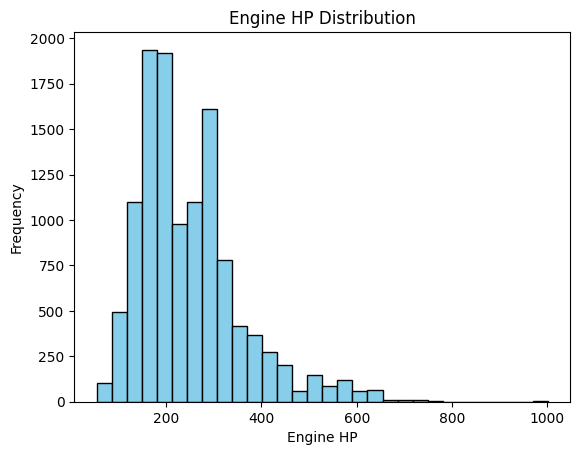

In [ ]:
df['Engine HP'].plot(kind='hist', bins=30, color='skyblue', edgecolor='black', title='Engine HP Distribution')
plt.xlabel('Engine HP')
plt.show()


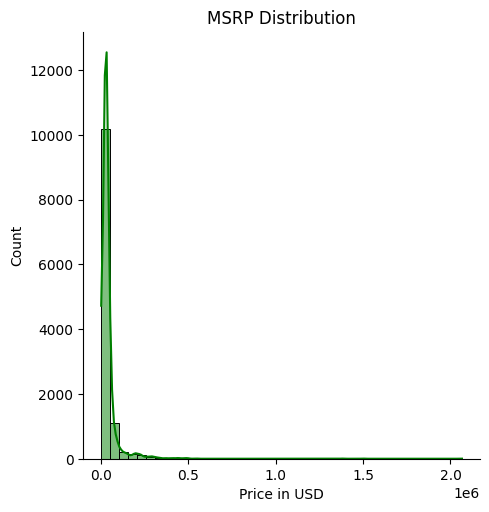

In [ ]:
sns.displot(df, x='MSRP', bins=40, kde=True, color='green')
plt.title('MSRP Distribution')
plt.xlabel('Price in USD')
plt.show()


<ipython-input-45-b737191bd029>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Vehicle Size', palette='pastel')


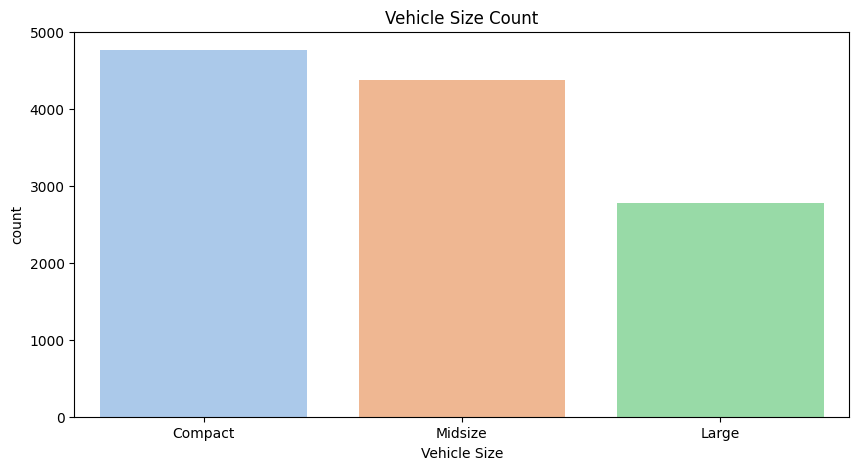

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Vehicle Size', palette='pastel')
plt.title('Vehicle Size Count')
plt.show()


<ipython-input-46-ec3163a8c7f5>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df[df['Make'].isin(top_makes)], y='Make', order=top_makes, palette='Set2')


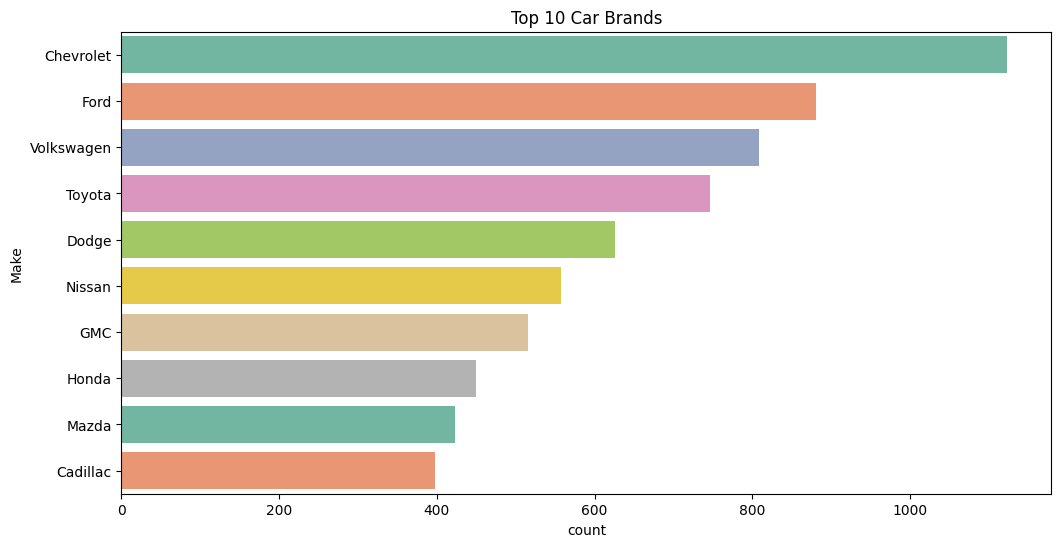

In [ ]:
top_makes = df['Make'].value_counts().nlargest(10).index
plt.figure(figsize=(12, 6))
sns.countplot(data=df[df['Make'].isin(top_makes)], y='Make', order=top_makes, palette='Set2')
plt.title('Top 10 Car Brands')
plt.show()


# **Bivariate Analysis**

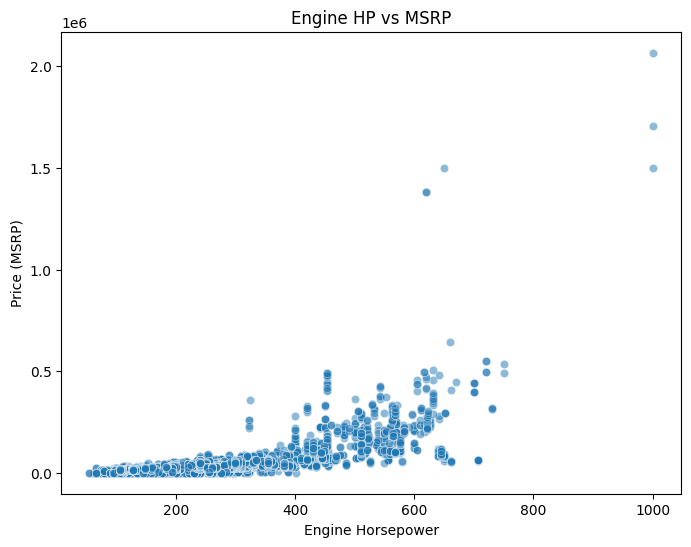

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Engine HP', y='MSRP', alpha=0.5)
plt.title('Engine HP vs MSRP')
plt.xlabel('Engine Horsepower')
plt.ylabel('Price (MSRP)')
plt.show()


<ipython-input-48-cc8e5e227ccc>:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Vehicle Size', y='MSRP', estimator='mean', ci=None, palette='muted')
<ipython-input-48-cc8e5e227ccc>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Vehicle Size', y='MSRP', estimator='mean', ci=None, palette='muted')


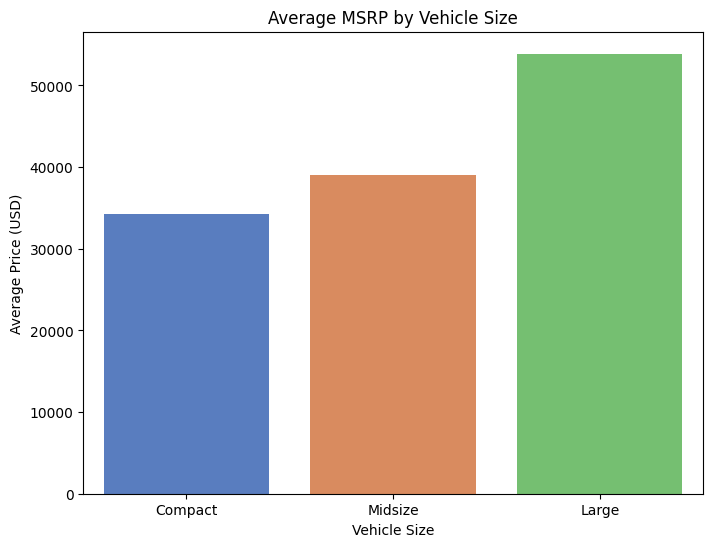

In [ ]:
plt.figure(figsize=(8, 6))
sns.barplot(data=df, x='Vehicle Size', y='MSRP', estimator='mean', ci=None, palette='muted')
plt.title('Average MSRP by Vehicle Size')
plt.ylabel('Average Price (USD)')
plt.show()


<ipython-input-49-2abef598bc35>:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df[df['Make'].isin(top_makes)], x='Make', y='Engine HP', estimator='mean', ci=None, palette='Set3')
<ipython-input-49-2abef598bc35>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df[df['Make'].isin(top_makes)], x='Make', y='Engine HP', estimator='mean', ci=None, palette='Set3')


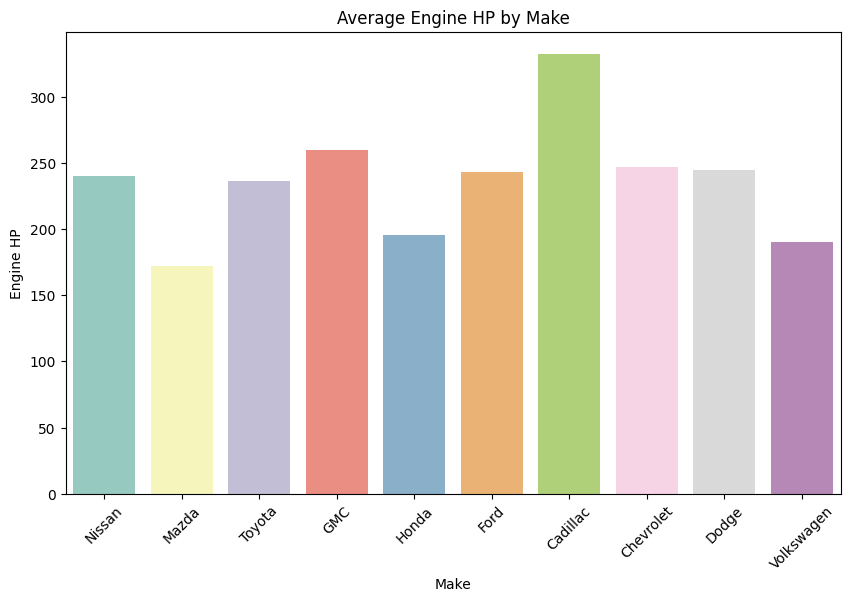

In [ ]:
top_makes = df['Make'].value_counts().nlargest(10).index
plt.figure(figsize=(10, 6))
sns.barplot(data=df[df['Make'].isin(top_makes)], x='Make', y='Engine HP', estimator='mean', ci=None, palette='Set3')
plt.xticks(rotation=45)
plt.title('Average Engine HP by Make')
plt.show()


<ipython-input-50-8f361139a0be>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Vehicle Size', y='MSRP', palette='cool')


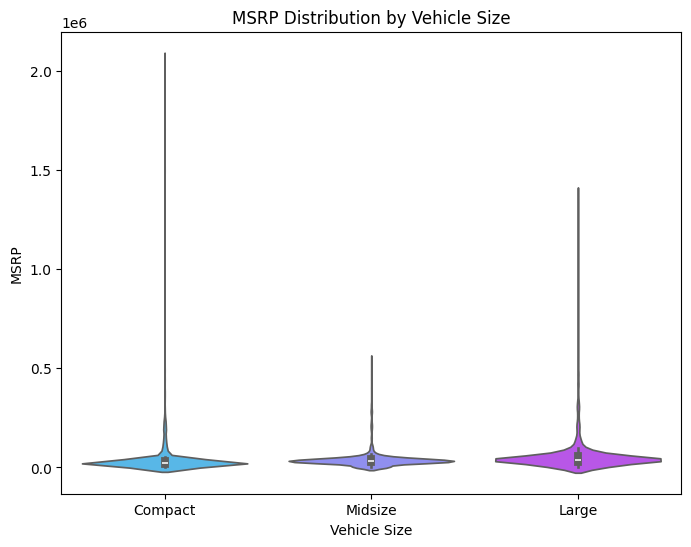

In [ ]:
plt.figure(figsize=(8, 6))
sns.violinplot(data=df, x='Vehicle Size', y='MSRP', palette='cool')
plt.title('MSRP Distribution by Vehicle Size')
plt.show()


<ipython-input-51-b1c7e87d97cc>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Transmission Type', y='Engine HP', palette='Set2')


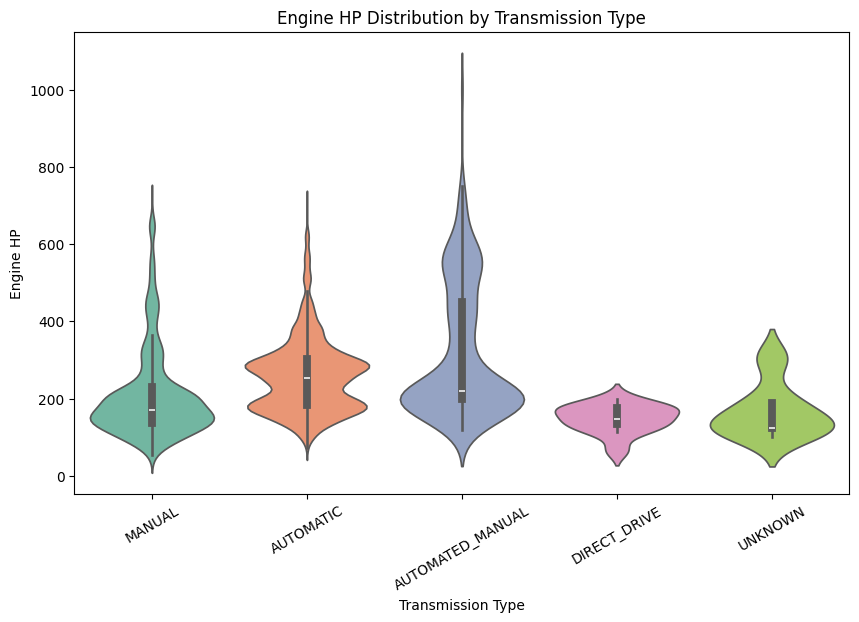

In [ ]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='Transmission Type', y='Engine HP', palette='Set2')
plt.title('Engine HP Distribution by Transmission Type')
plt.xticks(rotation=30)
plt.show()


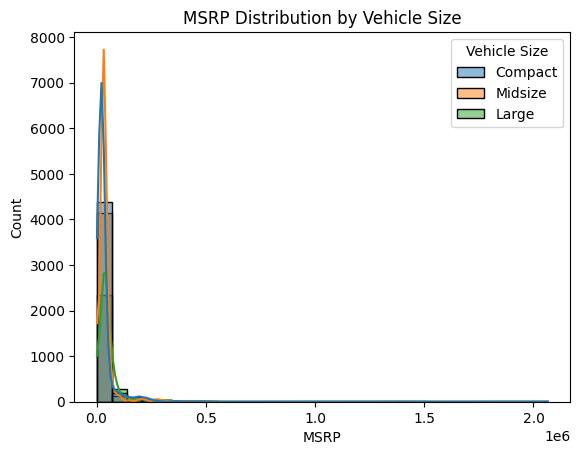

In [ ]:
sns.histplot(data=df, x='MSRP', hue='Vehicle Size', bins=30, kde=True)
plt.title("MSRP Distribution by Vehicle Size")
plt.show()

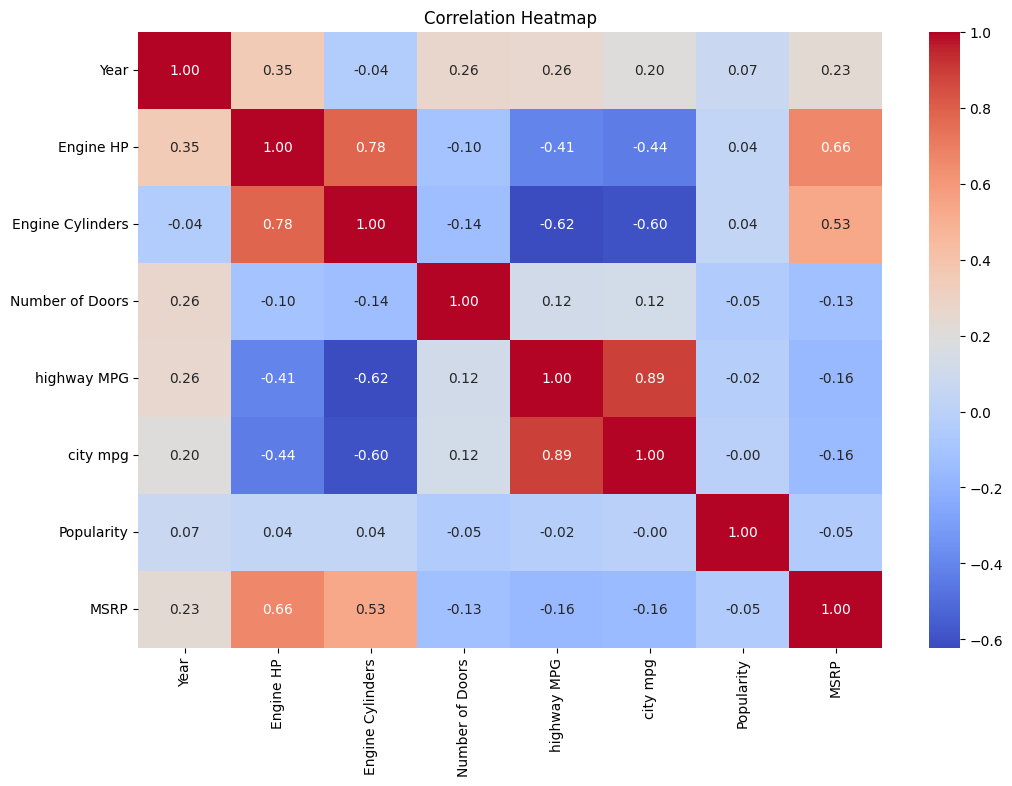

In [ ]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

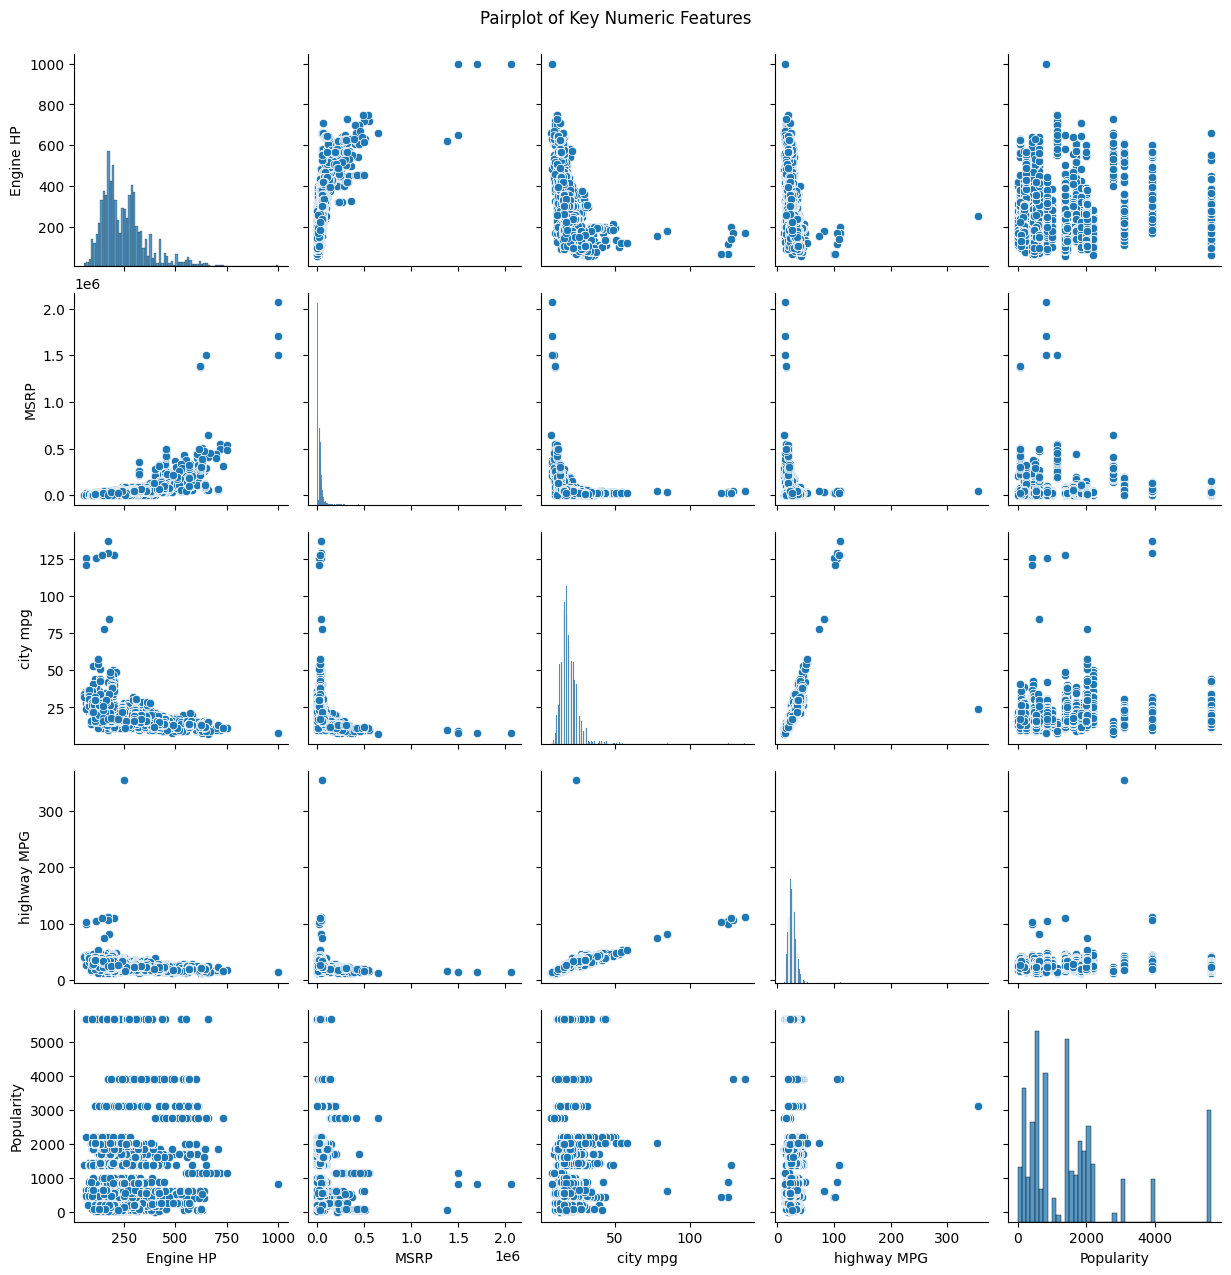

In [ ]:
selected_cols = ['Engine HP', 'MSRP', 'city mpg', 'highway MPG', 'Popularity']
sns.pairplot(df[selected_cols].dropna())
plt.suptitle("Pairplot of Key Numeric Features", y=1.02)
plt.show()

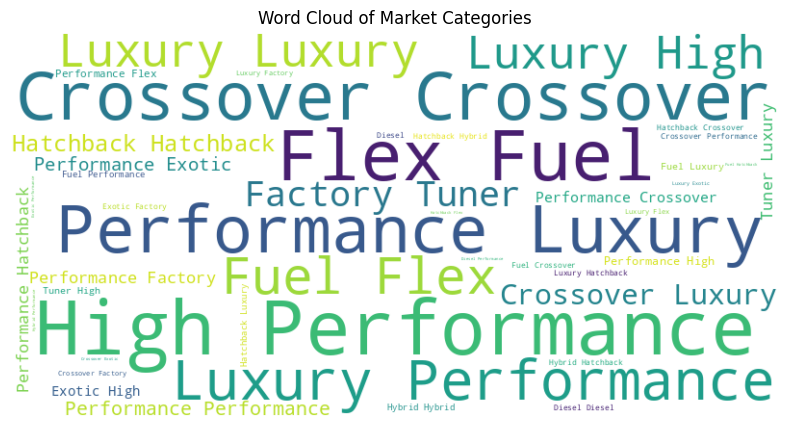

In [ ]:

# Combine all non-null values
text = ' '.join(df['Market Category'].dropna().astype(str))

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Market Categories")
plt.show()

# **EDA For Linear Models**

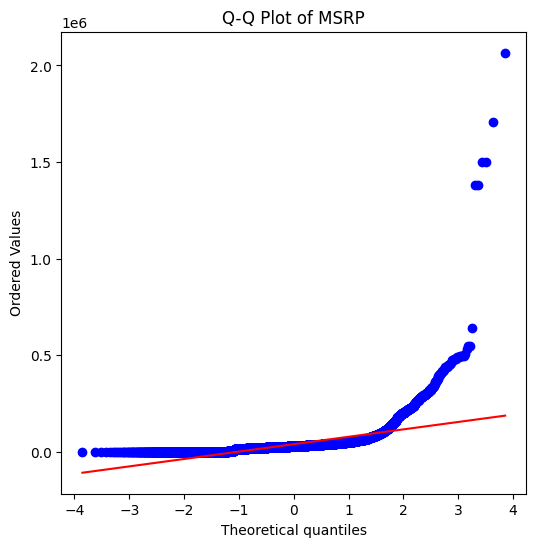

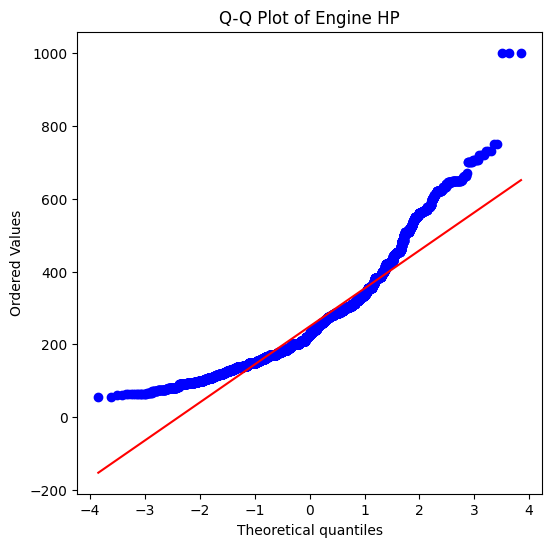

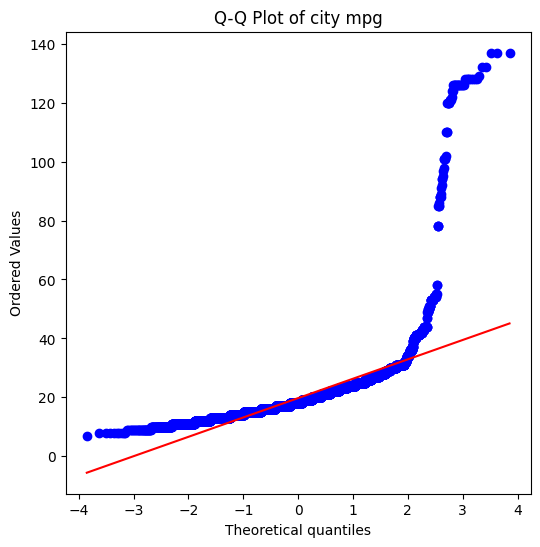

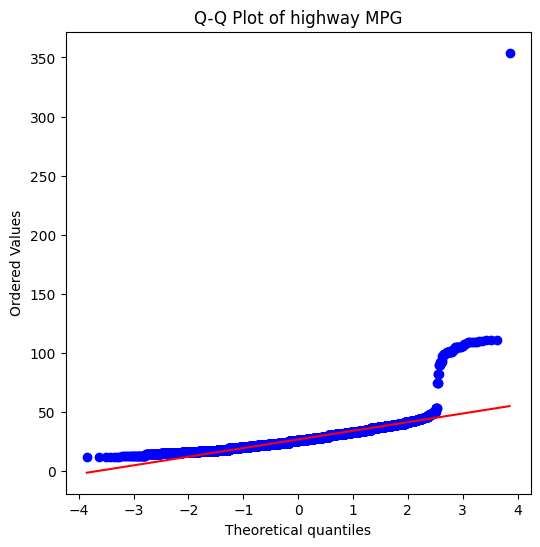

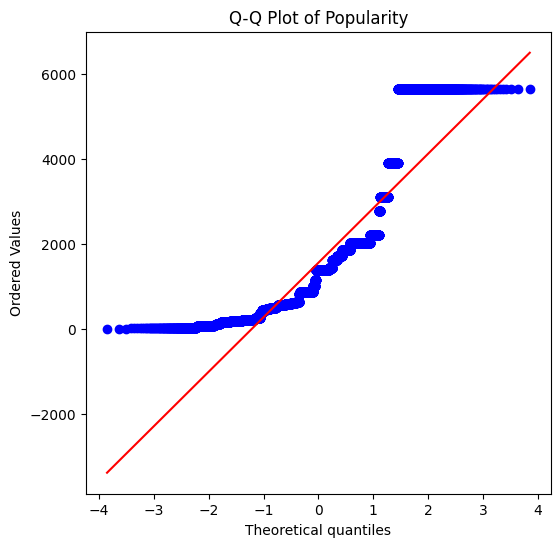

In [ ]:

cols = ['MSRP', 'Engine HP', 'city mpg', 'highway MPG', 'Popularity']

for col in cols:
    plt.figure(figsize=(6, 6))
    stats.probplot(df[col].dropna(), dist="norm", plot=plt)
    plt.title(f"Q-Q Plot of {col}")
    plt.show()


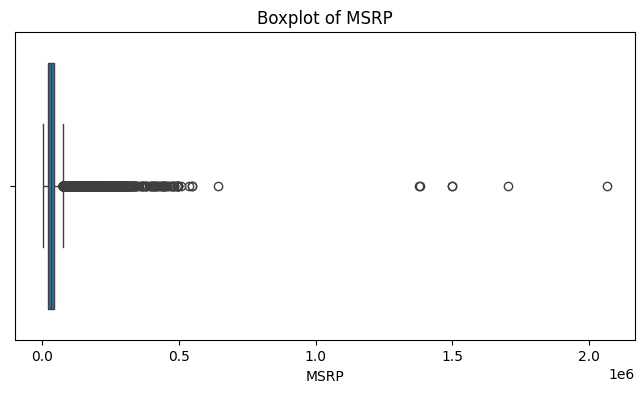

In [ ]:


plt.figure(figsize=(8, 4))
sns.boxplot(x=df['MSRP'])
plt.title("Boxplot of MSRP")
plt.show()


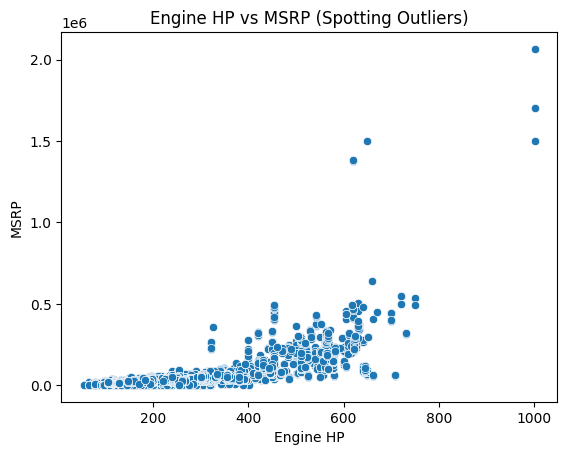

In [ ]:
sns.scatterplot(data=df, x='Engine HP', y='MSRP')
plt.title("Engine HP vs MSRP (Spotting Outliers)")
plt.show()


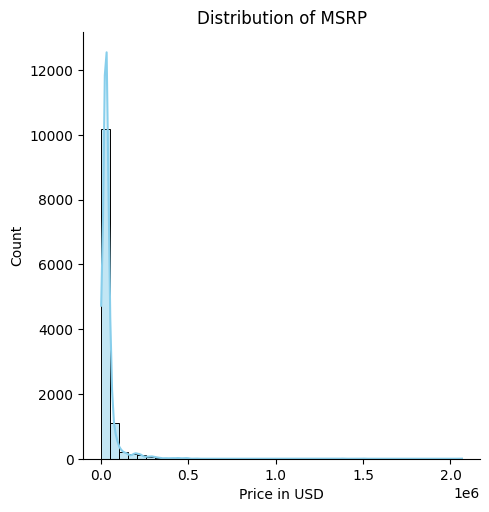

In [ ]:


sns.displot(df, x="MSRP", bins=40, kde=True, color='skyblue')
plt.title("Distribution of MSRP")
plt.xlabel("Price in USD")
plt.show()


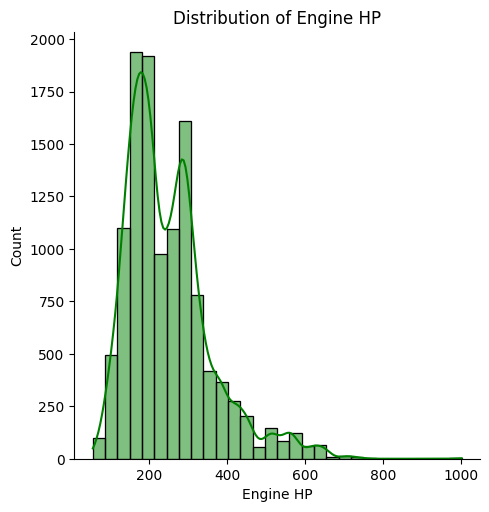

In [ ]:
sns.displot(df, x="Engine HP", bins=30, kde=True, color='green')
plt.title("Distribution of Engine HP")
plt.show()


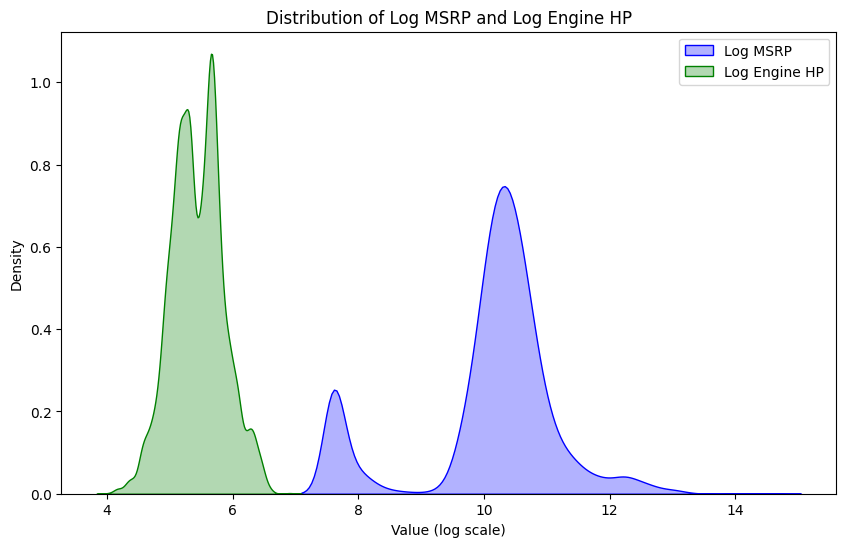

In [ ]:

# Log transform for better comparison
df['log_MSRP'] = np.log1p(df['MSRP'])
df['log_HP'] = np.log1p(df['Engine HP'])

plt.figure(figsize=(10, 6))
sns.kdeplot(df['log_MSRP'].dropna(), label='Log MSRP', color='blue', fill=True, alpha=0.3)
sns.kdeplot(df['log_HP'].dropna(), label='Log Engine HP', color='green', fill=True, alpha=0.3)

plt.title("Distribution of Log MSRP and Log Engine HP")
plt.xlabel("Value (log scale)")
plt.legend()
plt.show()

In [ ]:
cat_pairs = [
    ('Vehicle Size', 'Driven_Wheels'),
    ('Make', 'Vehicle Style'),
    ('Engine Fuel Type', 'Transmission Type'),
]

for col1, col2 in cat_pairs:
    print(f"\nChi-Square Test: {col1} vs {col2}")
    table = pd.crosstab(df[col1], df[col2])
    chi2, p, dof, expected = chi2_contingency(table)
    print(f"Chi2 = {chi2:.2f}, p-value = {p:.4f}")
    print("Dependent" if p < 0.05 else "Independent")


Chi-Square Test: Vehicle Size vs Driven_Wheels
Chi2 = 1965.31, p-value = 0.0000
Dependent

Chi-Square Test: Make vs Vehicle Style
Chi2 = 12486.89, p-value = 0.0000
Dependent

Chi-Square Test: Engine Fuel Type vs Transmission Type
Chi2 = 13040.93, p-value = 0.0000
Dependent


# **Machine Learning Model Building for Classification Problem**

🎯 Enter the target variable name: MSRP
📌 Enter the feature variable names (comma-separated): Engine HP, Engine Cylinders, Vehicle Size, Driven_Wheels

✅ Data split into training and test sets.
Training set size: 8945, Test set size: 2237

🔍 Tuning Random Forest...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

🔍 Tuning XGBoost...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

📊 Model Evaluation on Log-Transformed Target:

🔷 Linear Regression
Mean Squared Error (MSE): 157757434.76
R-squared (R²): 0.546
--------------------------------------------------
🔷 Decision Tree Regressor
Mean Squared Error (MSE): 30963786.86
R-squared (R²): 0.911
--------------------------------------------------
🔷 Random Forest (Tuned)
Mean Squared Error (MSE): 29264858.76
R-squared (R²): 0.916
--------------------------------------------------
🔷 XGBoost (Tuned)
Mean Squared Error (MSE): 33319264.70
R-squared (R²): 0.904
--------------------------------------------------


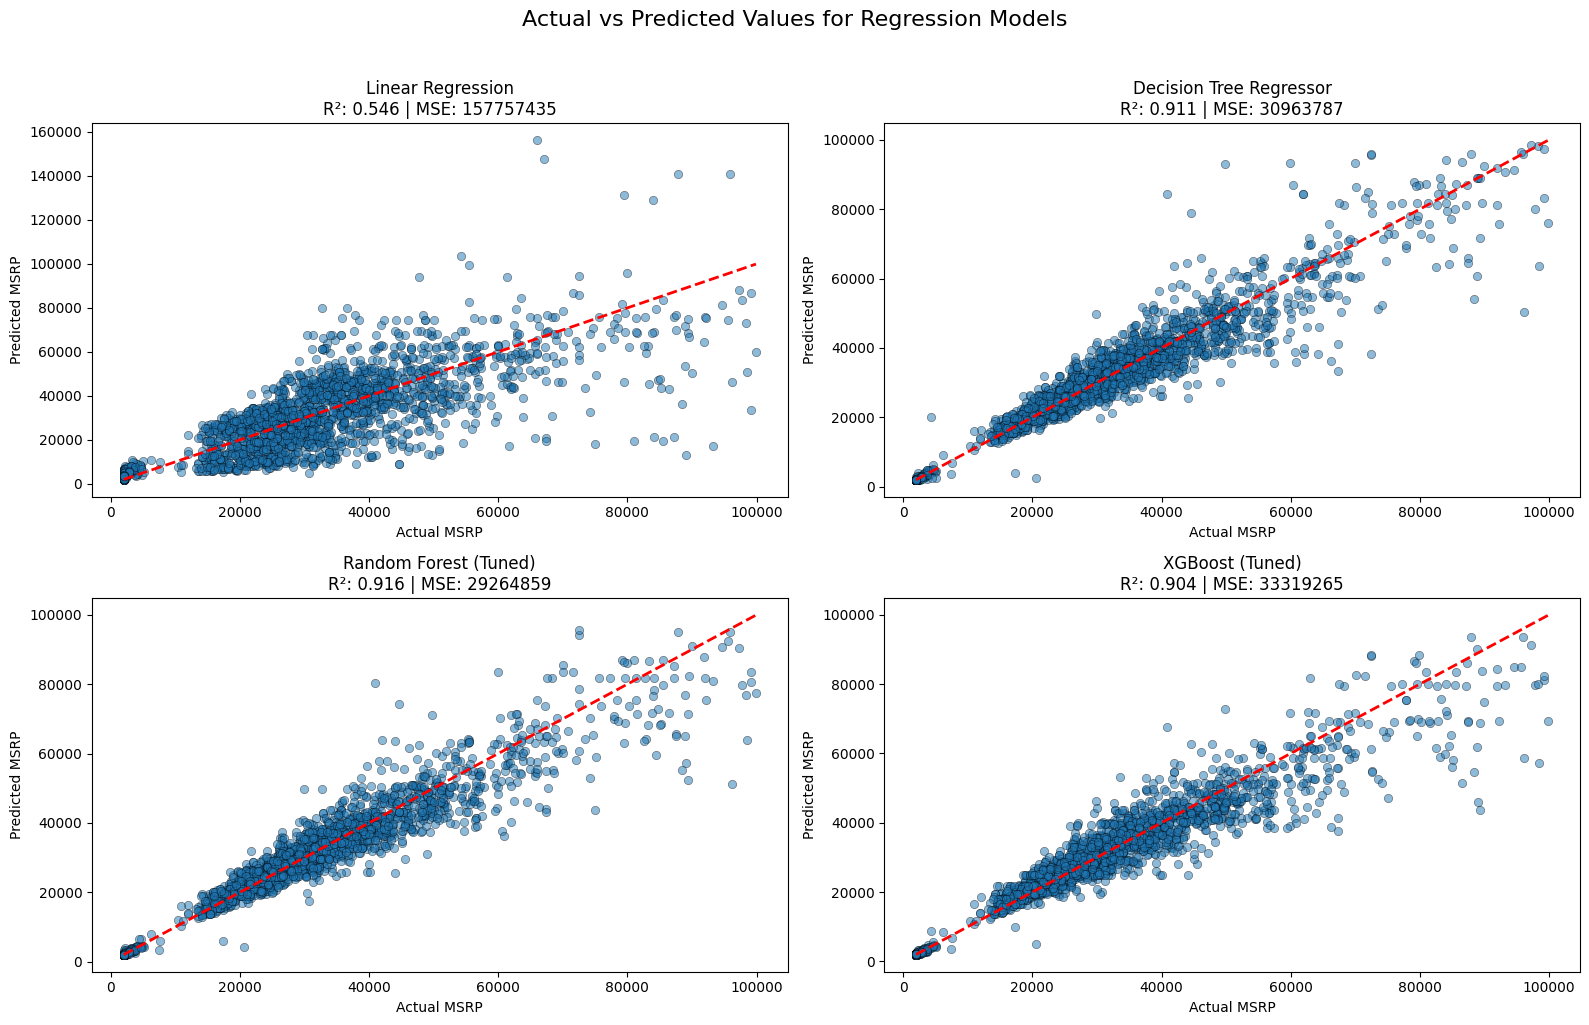

In [ ]:


class Data_Base_Modelling:

    def __init__(self):
        print("Data_Base_Modelling object created")

    def label_encoding(self, df):
        category_cols = [col for col in df.columns if df[col].dtypes == "object"]
        label_encoder = preprocessing.LabelEncoder()
        mapping_dict = {}
        for col in category_cols:
            df[col] = label_encoder.fit_transform(df[col])
            le_name_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
            mapping_dict[col] = le_name_mapping
        return mapping_dict

    def imputer(self, df):
        imp_mean = IterativeImputer(random_state=0)
        df_imputed = imp_mean.fit_transform(df)
        return pd.DataFrame(df_imputed, columns=df.columns)

    def run_model(self, x_train, y_train, x_test, y_test, model, model_name="Model"):
        pipeline = Pipeline([(f'{model_name}_classifier', model)])
        pipeline.fit(x_train, y_train)
        predictions = pipeline.predict(x_test)
        report = classification_report(y_test, predictions)
        print(f"Classification Report for {model_name}:\n")
        return report

    def logistic_regression(self, x_train, y_train, x_test, y_test):
        return self.run_model(x_train, y_train, x_test, y_test, LogisticRegression(), "LogisticRegression")

    def decision_tree(self, x_train, y_train, x_test, y_test):
        return self.run_model(x_train, y_train, x_test, y_test, DecisionTreeClassifier(), "DecisionTree")

    def random_forest(self, x_train, y_train, x_test, y_test):
        return self.run_model(x_train, y_train, x_test, y_test, RandomForestClassifier(), "RandomForest")

    def naive_bayes(self, x_train, y_train, x_test, y_test):
        return self.run_model(x_train, y_train, x_test, y_test, GaussianNB(), "NaiveBayes")

    def xgb_classifier(self, x_train, y_train, x_test, y_test):
        return self.run_model(x_train, y_train, x_test, y_test, XGBClassifier(), "XGBoost")
